In [1]:
%pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from copy import deepcopy
import os
import numpy as np

In [3]:
layer_skip_model_id = "facebook/layerskip-llama3.2-1B"

In [4]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

In [5]:
try:
    tokenizer = AutoTokenizer.from_pretrained(
        layer_skip_model_id,
        token=hf_token # Pass token if using Method 2 or explicitly using cached token
    )
    print("Tokenizer loaded successfully.")
except Exception as e:
    print(f"Error loading tokenizer: {e}")
    exit() # Exit if tokenizer fails, as model loading will also fail

# --- Loading Model ---
print(f"Loading model: {layer_skip_model_id}")

try:
    model = AutoModelForCausalLM.from_pretrained(
        layer_skip_model_id,
        token=hf_token,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    print("Model loaded successfully.")
    print(f"Model device map: {model.hf_device_map}")

except Exception as e:
    print(f"Error loading model: {e}")
    exit()

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer loaded successfully.
Loading model: facebook/layerskip-llama3.2-1B


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Model loaded successfully.
Model device map: {'': 0}


In [ ]:
%pip install transformer_lens
%pip install circuitsvis

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.2/189.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=2ce92d9bb23c068b3596c7dc31bd891043c485abb32f9fe25752d6933e4ece99
  Stored in directory: /root/.cache/pip/wheels/23/e8/f0/b3c58c12d1ffe60bcc8c7d121115f26b2c1878653edfca48db
Successfull

In [ ]:
import circuitsvis as cv

In [ ]:
# import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer, FactoredMatrix

In [ ]:
torch.set_grad_enabled(False)

In [ ]:
device = utils.get_device()

In [ ]:
llama_model_id = "meta-llama/Llama-3.2-1B"
skiplayer_model = HookedTransformer.from_pretrained(llama_model_id, hf_model = model, device=device, hf_token = hf_token)
llama_model = HookedTransformer.from_pretrained(llama_model_id, device=device)

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer


In [ ]:
test_text = """The river was overflowing, this caused damage to the surrounding areas."""
loss = skiplayer_model(test_text, return_type="loss")
print("skiplayer_model loss:", loss)

loss = llama_model(test_text, return_type="loss")
print("llama_model loss:", loss)

skiplayer_model loss: tensor(3.9239, device='cuda:0')
llama_model loss: tensor(3.8924, device='cuda:0')


In [ ]:
llama_model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [ ]:
skiplayer_model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [ ]:
test_tokens_skiplayer = skiplayer_model.to_tokens(test_text)
test_tokens_llama = llama_model.to_tokens(test_text)

skiplayer_logits, skiplayer_cache = skiplayer_model.run_with_cache(test_tokens_skiplayer, remove_batch_dim=True)
llama_logits, llama_cache = llama_model.run_with_cache(test_tokens_llama, remove_batch_dim=True)

In [ ]:
num_attention_heads = llama_model.cfg.n_heads
num_layers = llama_model.cfg.n_layers

# attention patterns
No interesting patterns were found between skiplayer and llama

In [ ]:
for i in range(len(llama_model.blocks)):
    attention_pattern = llama_cache["pattern", i, "attn"]
    print(attention_pattern.shape)
    llama_str_tokens = llama_model.to_str_tokens(test_text)
    print(f"llama model Layer {i} Head Attention Patterns:")
    display(cv.attention.attention_patterns(tokens=llama_str_tokens, attention=attention_pattern))

    attention_pattern = skiplayer_cache["pattern", i, "attn"]
    print(attention_pattern.shape)
    skiplayer_str_tokens = skiplayer_model.to_str_tokens(test_text)
    print(f"skiplayer model Layer {i} Head Attention Patterns:")
    display(cv.attention.attention_patterns(tokens=skiplayer_str_tokens, attention=attention_pattern))

torch.Size([32, 15, 15])
llama model Layer 0 Head Attention Patterns:


torch.Size([32, 15, 15])
skiplayer model Layer 0 Head Attention Patterns:


torch.Size([32, 15, 15])
llama model Layer 1 Head Attention Patterns:


torch.Size([32, 15, 15])
skiplayer model Layer 1 Head Attention Patterns:


torch.Size([32, 15, 15])
llama model Layer 2 Head Attention Patterns:


...

torch.Size([32, 15, 15])
skiplayer model Layer 29 Head Attention Patterns:


torch.Size([32, 15, 15])
llama model Layer 30 Head Attention Patterns:


torch.Size([32, 15, 15])
skiplayer model Layer 30 Head Attention Patterns:


torch.Size([32, 15, 15])
llama model Layer 31 Head Attention Patterns:


torch.Size([32, 15, 15])
skiplayer model Layer 31 Head Attention Patterns:


# measuring inference times
no significant difference in execution times  

In [ ]:
import time

t0 = time.time()
for i in range(10):
    test_tokens_skiplayer = skiplayer_model.to_tokens(test_text)
    skiplayer_logits, skiplayer_cache = skiplayer_model.run_with_cache(test_tokens_skiplayer, remove_batch_dim=True)
t1 = time.time()
print(t1-t0)

t0 = time.time()
for i in range(10):
    test_tokens_llama = llama_model.to_tokens(test_text)
    llama_logits, llama_cache = llama_model.run_with_cache(test_tokens_llama, remove_batch_dim=True)
t1 = time.time()
print(t1-t0)

266.3886172771454
262.70214104652405


# examining the effect of 0 ablation on different heads/ layers

In [ ]:
def get_ablation_heatmap_full(model,text):
    ablation_res = np.zeros((num_layers))
    text_tokens = model.to_tokens(text)

    def head_ablation_hook(value,hook):
        value[:, :, :, :] = 0.
        return value

    for layer_number in range(num_layers):
        original_loss = model(text_tokens, return_type="loss")
        ablated_loss = model.run_with_hooks(
            text_tokens,
            return_type="loss",
            fwd_hooks=[(
                utils.get_act_name("v", layer_number),
                head_ablation_hook
                )]
            )
        ablation_res[layer_number] = ablated_loss.item()/original_loss.item()
    return ablation_res

def get_ablation_heatmap_nodes(model,text):
    ablation_res = np.zeros((num_layers,num_attention_heads))
    text_tokens = model.to_tokens(text)

    for layer_number in range(num_layers):
        for head_number in (range(num_attention_heads)):
            def head_ablation_hook(value,hook):
                value[:, :, head_number, :] = 0.
                return value

            original_loss = model(text_tokens, return_type="loss")
            ablated_loss = model.run_with_hooks(
                text_tokens,
                return_type="loss",
                fwd_hooks=[(
                    utils.get_act_name("v", layer_number),
                    head_ablation_hook
                    )]
                )
            ablation_res[layer_number,head_number] = ablated_loss.item()/original_loss.item()
    return ablation_res

In [ ]:
sample_text = """Sam was preparing for the presentation this week. He was waiting for the content being prepared by John to finalize everything, and was getting worried so he called"""
llama_ablation_heatmap = get_ablation_heatmap_full(llama_model,sample_text)
skiplayer_ablation_heatmap = get_ablation_heatmap_full(skiplayer_model,sample_text)

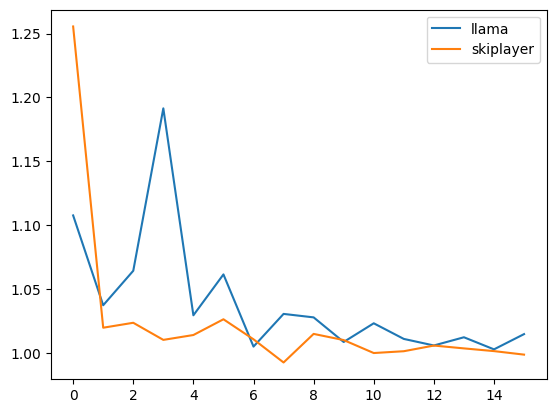

In [ ]:
import matplotlib.pyplot as plt
plt.plot(llama_ablation_heatmap,label = "llama")
plt.plot(skiplayer_ablation_heatmap,label = "skiplayer")
plt.legend()

## Testing ablation losses on varying sentence lengths

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

movie_dataset = pd.read_csv("./mpst_full_data.csv")
movie_dataset["word_len"] = [i for i in map(lambda x: len(x.split()),movie_dataset["plot_synopsis"])]
movie_dataset_sorted = movie_dataset.sort_values("word_len")

examples_per_len = 10
word_counts = [250,500,1000,2000]

ablation_values_llama = []
ablation_values_skiplayer = []
examples = []
for seq_len in [250,500,1000,2000]:
    for i in range(examples_per_len):
        print(f"seq:{seq_len} - example_num{i}")
        ind = np.argmax(movie_dataset_sorted["word_len"].values>seq_len)
        processed_example = " ".join(movie_dataset_sorted["plot_synopsis"].values[ind+i].split()[:seq_len])
        examples.append(processed_example)

        ablation_values_llama.append(get_ablation_heatmap_full(llama_model,processed_example))
        ablation_values_skiplayer.append(get_ablation_heatmap_full(skiplayer_model,processed_example))


seq:250 - example_num0
seq:250 - example_num1
seq:250 - example_num2
seq:250 - example_num3
seq:250 - example_num4
seq:250 - example_num5
seq:250 - example_num6
seq:250 - example_num7
seq:250 - example_num8
seq:250 - example_num9
seq:500 - example_num0
seq:500 - example_num1
seq:500 - example_num2
seq:500 - example_num3
seq:500 - example_num4
seq:500 - example_num5
seq:500 - example_num6
seq:500 - example_num7
seq:500 - example_num8
seq:500 - example_num9
seq:1000 - example_num0
seq:1000 - example_num1
seq:1000 - example_num2
seq:1000 - example_num3
seq:1000 - example_num4
seq:1000 - example_num5
seq:1000 - example_num6
seq:1000 - example_num7
seq:1000 - example_num8
seq:1000 - example_num9
seq:2000 - example_num0
seq:2000 - example_num1
seq:2000 - example_num2
seq:2000 - example_num3
seq:2000 - example_num4
seq:2000 - example_num5
seq:2000 - example_num6
seq:2000 - example_num7
seq:2000 - example_num8
seq:2000 - example_num9


In [ ]:
llama_ablation_df = pd.DataFrame(ablation_values_llama)
skiplayer_ablation_df = pd.DataFrame(ablation_values_skiplayer)

llama_ablation_df.to_csv("./llama_ablation_df.csv")
skiplayer_ablation_df.to_csv("./skiplayer_ablation_df.csv")

# llama_ablation_df = pd.read_csv("./llama_ablation_df.csv",index_col=0)
# skiplayer_ablation_df = pd.read_csv("./skiplayer_ablation_df.csv",index_col=0)

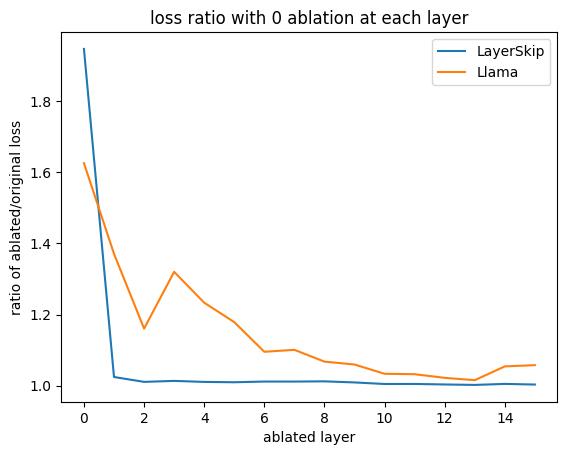

In [ ]:
plt.plot(np.mean(skiplayer_ablation_df,axis = 0),label = "LayerSkip")
plt.plot(np.mean(llama_ablation_df,axis = 0),label = "Llama")
plt.title("loss ratio with 0 ablation at each layer")
plt.ylabel("ratio of ablated/original loss")
plt.xlabel("ablated layer")
plt.legend()

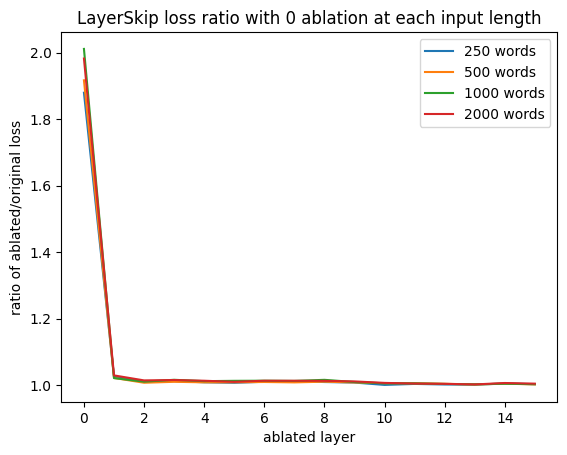

In [ ]:
plt.plot(np.mean(skiplayer_ablation_df.iloc[:10,:],axis = 0),label = "250 words")
plt.plot(np.mean(skiplayer_ablation_df.iloc[10:20,:],axis = 0),label = "500 words")
plt.plot(np.mean(skiplayer_ablation_df.iloc[20:30,:],axis = 0),label = "1000 words")
plt.plot(np.mean(skiplayer_ablation_df.iloc[30:,:],axis = 0),label = "2000 words")
plt.title("LayerSkip loss ratio with 0 ablation at each input length")
plt.ylabel("ratio of ablated/original loss")
plt.xlabel("ablated layer")
plt.legend()

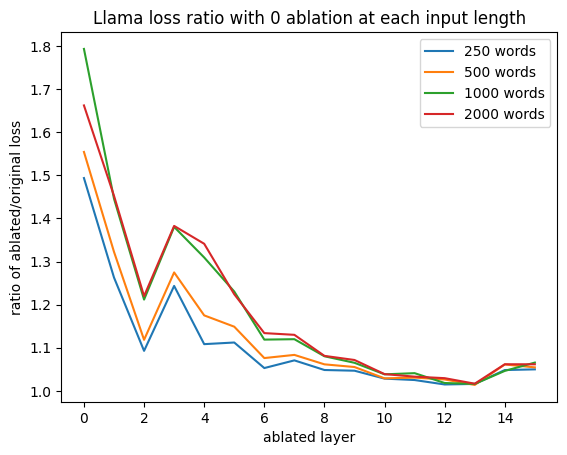

In [ ]:
plt.plot(np.mean(llama_ablation_df.iloc[:10,:],axis = 0),label = "250 words")
plt.plot(np.mean(llama_ablation_df.iloc[10:20,:],axis = 0),label = "500 words")
plt.plot(np.mean(llama_ablation_df.iloc[20:30,:],axis = 0),label = "1000 words")
plt.plot(np.mean(llama_ablation_df.iloc[30:,:],axis = 0),label = "2000 words")
plt.title("Llama loss ratio with 0 ablation at each input length")
plt.ylabel("ratio of ablated/original loss")
plt.xlabel("ablated layer")
plt.legend()

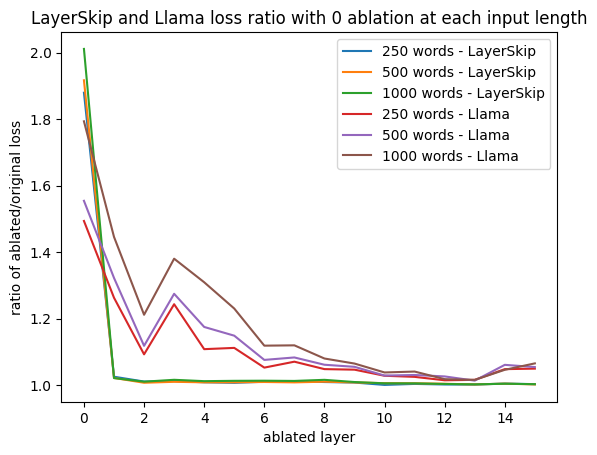

In [ ]:
plt.plot(np.mean(skiplayer_ablation_df.iloc[:10,:],axis = 0),label = "250 words - LayerSkip")
plt.plot(np.mean(skiplayer_ablation_df.iloc[10:20,:],axis = 0),label = "500 words - LayerSkip")
plt.plot(np.mean(skiplayer_ablation_df.iloc[20:30,:],axis = 0),label = "1000 words - LayerSkip")
plt.plot(np.mean(llama_ablation_df.iloc[:10,:],axis = 0),label = "250 words - Llama")
plt.plot(np.mean(llama_ablation_df.iloc[10:20,:],axis = 0),label = "500 words - Llama")
plt.plot(np.mean(llama_ablation_df.iloc[20:30,:],axis = 0),label = "1000 words - Llama")

plt.title("LayerSkip and Llama loss ratio with 0 ablation at each input length")
plt.ylabel("ratio of ablated/original loss")
plt.xlabel("ablated layer")
plt.legend()

# Experiments to be implemented
- compare the activations at different layer cutoffs between layerskip and llama
- compare the activations at different transformer heads at the layer cutoffs between layerskip and llama
- compare the risidual streams from different layers between layerskip and llama
- check this paper and implement its insights: https://arxiv.org/html/2312.12141v1
- We can train simple linear models to perform specific tasks (sentiment analysis for example) using internal model activations. This should theoretically be more successful in earlier layers with skiplayer than llama

# Implementing Model Probing

In [ ]:
import pandas as pd
sentiment_df = pd.read_csv("./tweet_sentiment.csv")

In [ ]:
sentiment_df

,tweet,sentiment
0,The event starts at 5 PM.,neutral
1,I hate how this turned out.,negative
2,Fantastic experience!,positive
3,Fantastic experience!,positive
4,This is the worst thing ever!,negative
...,...,...
995,It’s cloudy outside.,neutral
996,Great job by the team!,positive
997,I'm so happy about the news!,positive
998,It ruined my whole day.,negative


In [ ]:
sentiment_df.shape[0]

1000

In [ ]:
llama_model_mlp_caches = np.zeros((llama_model.cfg.d_model,llama_model.cfg.n_layers,sentiment_df.shape[0]))
skiplayer_model_mlp_caches = np.zeros((skiplayer_model.cfg.d_model,skiplayer_model.cfg.n_layers,sentiment_df.shape[0]))

for example_num,example in enumerate(sentiment_df["tweet"]):
    if example_num%100==0:
        print(example_num)
    llama_tokens = llama_model.to_tokens(example)
    _, llama_cache = llama_model.run_with_cache(llama_tokens, remove_batch_dim=True)

    skiplayer_tokens = skiplayer_model.to_tokens(example)
    _, skiplayer_cache = skiplayer_model.run_with_cache(skiplayer_tokens, remove_batch_dim=True)

    for layer_num in range(llama_model.cfg.n_layers):
        llama_model_mlp_caches[:,layer_num,example_num] = llama_cache["resid_post", layer_num][-1,:].cpu()
        skiplayer_model_mlp_caches[:,layer_num,example_num] = skiplayer_cache["resid_post", layer_num][-1,:].cpu()
        # llama_model_mlp_caches[:,layer_num,example_num] = torch.mean(llama_cache["mlp_out", layer_num],0).cpu()
        # skiplayer_model_mlp_caches[:,layer_num,example_num] = torch.mean(skiplayer_cache["mlp_out", layer_num],0).cpu()

0


<ipython-input-20-5c02ddcaddab>:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  llama_model_mlp_caches[:,layer_num,example_num] = llama_cache["resid_post", layer_num][-1,:].cpu()
<ipython-input-20-5c02ddcaddab>:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  skiplayer_model_mlp_caches[:,layer_num,example_num] = skiplayer_cache["resid_post", layer_num][-1,:].cpu()


KeyboardInterrupt: 

In [ ]:
y = torch.tensor([-1 if label=="negative" else 0 if label == "neutral" else 1 for label in sentiment_df["sentiment"]]).float()
y.shape

In [ ]:
import pickle
# with open('llama_model_mlp_caches.pkl', 'wb') as file:
#     pickle.dump(llama_model_mlp_caches, file)

# with open('skiplayer_model_mlp_caches.pkl', 'wb') as file:
#     pickle.dump(skiplayer_model_mlp_caches, file)

# with open('llama_model_mlp_caches.pkl', 'rb') as f:
#     llama_model_mlp_caches = pickle.load(f)

# with open('skiplayer_model_mlp_caches.pkl', 'rb') as f:
#     skiplayer_model_mlp_caches = pickle.load(f)

In [ ]:
skiplayer_model_mlp_caches.shape

In [ ]:
import torch
import torch.optim as optim

In [ ]:
torch.set_grad_enabled(True)

class RegressionModel(torch.nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(llama_model.cfg.d_model, int(llama_model.cfg.d_model)),
            torch.nn.ReLU(),
            torch.nn.Linear(llama_model.cfg.d_model, int(llama_model.cfg.d_model)),
            torch.nn.ReLU(),
            torch.nn.Linear(int(llama_model.cfg.d_model), 1)
        )


    def forward(self, x):
        return self.model(x)

class ClassifierModel(torch.nn.Module):
    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.model = torch.nn.Sequential(
            # torch.nn.Linear(llama_model.cfg.d_model, int(llama_model.cfg.d_model)),
            # torch.nn.ReLU(),
            # torch.nn.Linear(llama_model.cfg.d_model, int(llama_model.cfg.d_model)),
            # torch.nn.ReLU(),
            torch.nn.Linear(int(llama_model.cfg.d_model), 3)
        )


    def forward(self, x):
        return self.model(x)

In [ ]:
def train_regression_model(input_data,y):
    model = RegressionModel()
    criterion = torch.nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.0001)
    epochs = 200
    losses = []

    for epoch in range(epochs):
        model.train()

        y_pred = model(torch.tensor(input_data).float().T)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.detach())
    return y_pred.detach(),losses

def train_classification_model(input_data,y):
    model = ClassifierModel()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.0005)
    epochs = 200
    losses = []

    for epoch in range(epochs):
        model.train()

        y_pred = model(torch.tensor(input_data).float().T)
        loss = criterion(y_pred, torch.tensor(y).long())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.detach())
    return y_pred.detach(),losses

In [ ]:
probing_results_regression = [train_regression_model(skiplayer_model_mlp_caches[:,i,:],y) for i in range(num_layers)]

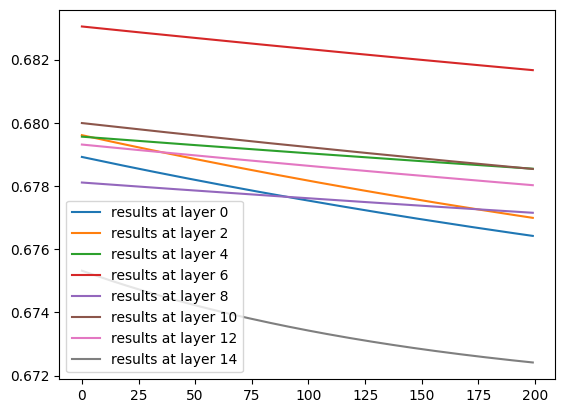

In [ ]:
import matplotlib.pyplot as plt
for i in range(0,num_layers,2):
    plt.plot(probing_results_regression[i][1], label = f"results at layer {i}")
    plt.legend()
plt.show()

In [ ]:
probing_results_classification_skiplayer = [train_classification_model(skiplayer_model_mlp_caches[:,i,:],y+1) for i in range(num_layers)]

In [ ]:
probing_results_classification_llama = [train_classification_model(llama_model_mlp_caches[:,i,:],y+1) for i in range(num_layers)]

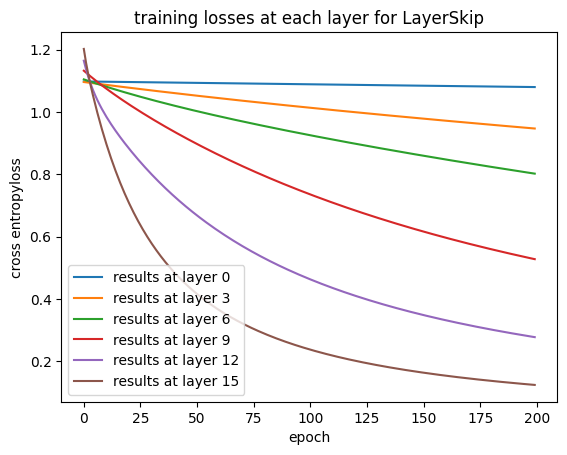

In [ ]:
import matplotlib.pyplot as plt
for i in range(0,num_layers,3):
    plt.plot(probing_results_classification_skiplayer[i][1], label = f"results at layer {i}")
    plt.legend()
    plt.title("training losses at each layer for LayerSkip")
    plt.xlabel("epoch")
    plt.ylabel("cross entropyloss")
plt.show()

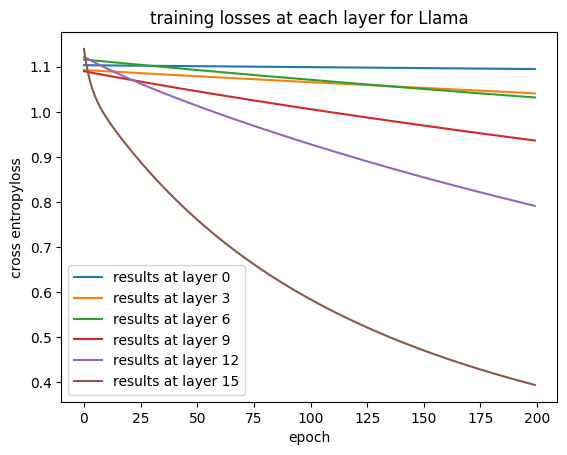

In [ ]:
import matplotlib.pyplot as plt
for i in range(0,num_layers,3):
    plt.plot(probing_results_classification_llama[i][1], label = f"results at layer {i}")
    plt.legend()
plt.title("training losses at each layer for Llama")
plt.xlabel("epoch")
plt.ylabel("cross entropyloss")
plt.show()

Text(0, 0.5, 'accuracy')

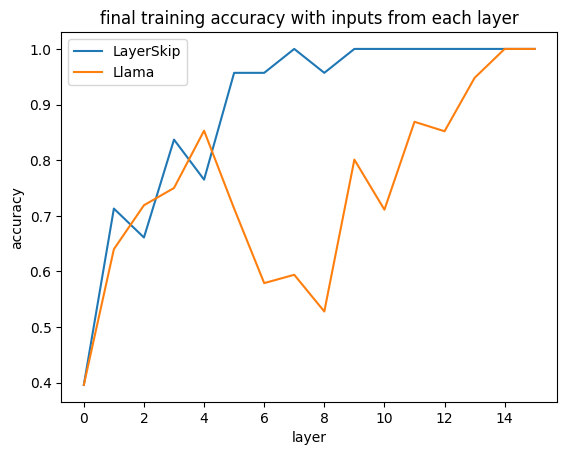

In [ ]:
plt.plot([np.mean((torch.argmax(res[0],dim = 1)==(y+1)).numpy()) for res in probing_results_classification_skiplayer],label = "LayerSkip")
plt.plot([np.mean((torch.argmax(res[0],dim = 1)==(y+1)).numpy()) for res in probing_results_classification_llama],label = "Llama")
plt.legend()
plt.title("final training accuracy with inputs from each layer")
plt.xlabel("layer")
plt.ylabel("accuracy")

# Activation Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
sentiment_df = pd.read_csv("./tweet_sentiment.csv")

(array([28.,  0.,  0.,  0.,  0., 36.,  0.,  0.,  0., 36.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

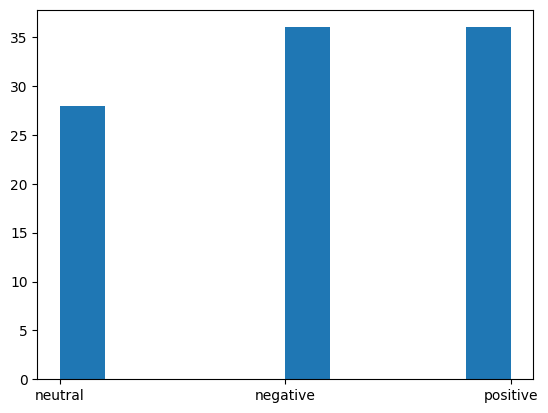

In [ ]:
plt.hist(sentiment_df["sentiment"][:100])

In [ ]:
llama_caches = []
skiplayer_caches = []

for example_num,example in enumerate(sentiment_df["tweet"][:100]):
    if example_num%100==0:
        print(example_num)
    llama_tokens = llama_model.to_tokens(example)
    _, llama_cache = llama_model.run_with_cache(llama_tokens, remove_batch_dim=True)

    skiplayer_tokens = skiplayer_model.to_tokens(example)
    _, skiplayer_cache = skiplayer_model.run_with_cache(skiplayer_tokens, remove_batch_dim=True)

    llama_caches.append(llama_cache)
    skiplayer_caches.append(skiplayer_cache)

0


In [ ]:
positive_skiplayer_caches = list(itertools.compress(skiplayer_caches,sentiment_df["sentiment"].values[:100]=="positive"))
negative_skiplayer_caches = list(itertools.compress(skiplayer_caches,sentiment_df["sentiment"].values[:100]=="negative"))

positive_llama_caches = list(itertools.compress(llama_caches,sentiment_df["sentiment"].values[:100]=="positive"))
negative_llama_caches = list(itertools.compress(llama_caches,sentiment_df["sentiment"].values[:100]=="negative"))

model_size = llama_model.cfg.d_model

In [ ]:
def get_item_values(cache_list,item,layer):
    output = []
    for example in cache_list:
        output.append(example[item,layer])
    return output

def get_activation_histograms(cache_list,item):
    output = torch.zeros((layer_num,model_size,len(cache_list)))
    for layer in range(layer_num):
        for cache_ind,cache in enumerate(get_item_values(cache_list,item,layer)):
            output[layer,:,cache_ind] = cache[-1,:]
    return output


In [ ]:
positive_skiplayer_mean = torch.mean(get_activation_histograms(positive_skiplayer_caches,"resid_post"),dim = 2)
negative_skiplayer_mean = torch.mean(get_activation_histograms(negative_skiplayer_caches,"resid_post"),dim = 2)

positive_llama_mean = torch.mean(get_activation_histograms(positive_llama_caches,"resid_post"),dim = 2)
negative_llama_mean = torch.mean(get_activation_histograms(negative_llama_caches,"resid_post"),dim = 2)

In [ ]:
positive_skiplayer_mean.shape

torch.Size([15, 2048])

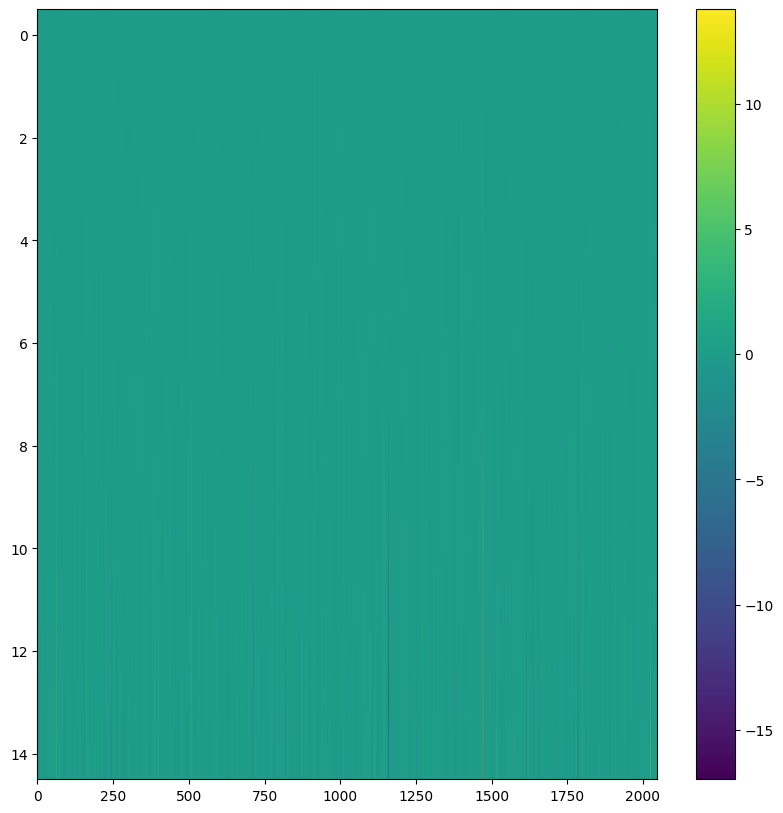

In [ ]:
plt.figure(figsize = (10,10))
plt.imshow(positive_skiplayer_mean, aspect='auto')
plt.colorbar()

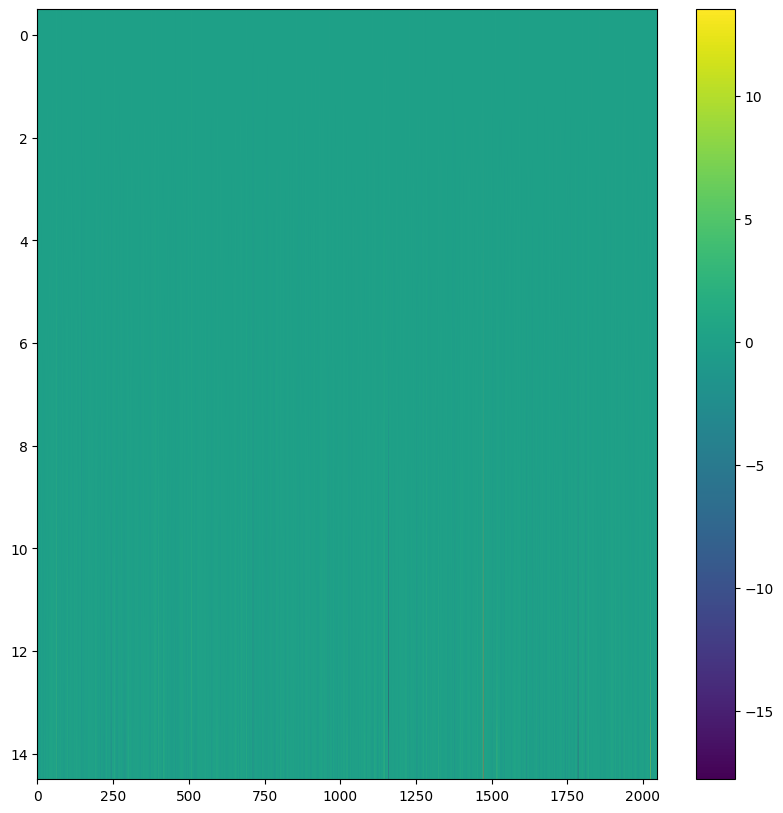

In [ ]:
plt.figure(figsize = (10,10))
plt.imshow(negative_skiplayer_mean, aspect='auto')
plt.colorbar()

In [ ]:
for i in positive_skiplayer_caches:
    print(i)

In [ ]:
x = torch.randn(3, 4)
x

tensor([[-0.9461, -0.5312, -0.4094, -1.2684],
        [ 0.7150, -1.2013, -0.4861, -0.1503],
        [-3.8256, -0.3199,  2.4829, -0.3326]])

In [ ]:
sorted, indices = torch.sort(x,dim = 1)
sorted

tensor([[-1.2684, -0.9461, -0.5312, -0.4094],
        [-1.2013, -0.4861, -0.1503,  0.7150],
        [-3.8256, -0.3326, -0.3199,  2.4829]])